## GPT가 수정해준 버전

🔍 데이터 로딩 및 특징 추출 시작...


none: 100%|██████████| 6590/6590 [00:44<00:00, 148.11it/s]


✅ 데이터셋 shape: (14668, 12) (14668,)
📊 클래스 가중치: {0: 2.332803180914513, 1: 0.9290577988915281, 2: 1.290869086908691, 3: 2.0622144112478034, 4: 0.4473503621807091}
Epoch 1/300
184/184 [==============================] - 1s 3ms/step - loss: 0.7268 - accuracy: 0.5799 - val_loss: 0.6714 - val_accuracy: 0.6483
Epoch 2/300
184/184 [==============================] - 0s 2ms/step - loss: 0.5063 - accuracy: 0.6639 - val_loss: 0.5881 - val_accuracy: 0.7198
Epoch 3/300
184/184 [==============================] - 0s 2ms/step - loss: 0.4637 - accuracy: 0.7034 - val_loss: 0.5630 - val_accuracy: 0.7324
Epoch 4/300
184/184 [==============================] - 0s 2ms/step - loss: 0.4394 - accuracy: 0.7240 - val_loss: 0.5187 - val_accuracy: 0.7662
Epoch 5/300
184/184 [==============================] - 0s 2ms/step - loss: 0.4267 - accuracy: 0.7362 - val_loss: 0.5030 - val_accuracy: 0.7689
Epoch 6/300
184/184 [==============================] - 0s 2ms/step - loss: 0.4078 - accuracy: 0.7477 - val_loss: 0.5110 - val

c:\Users\SSAFY\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


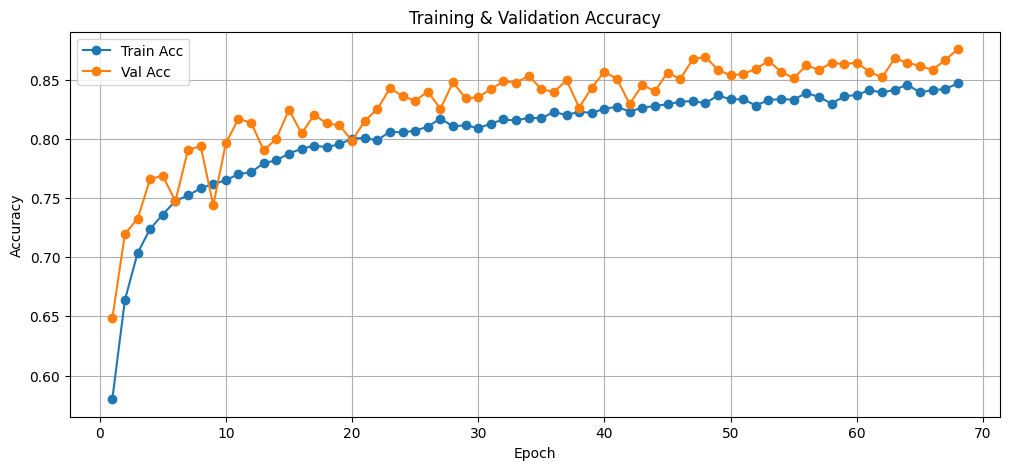

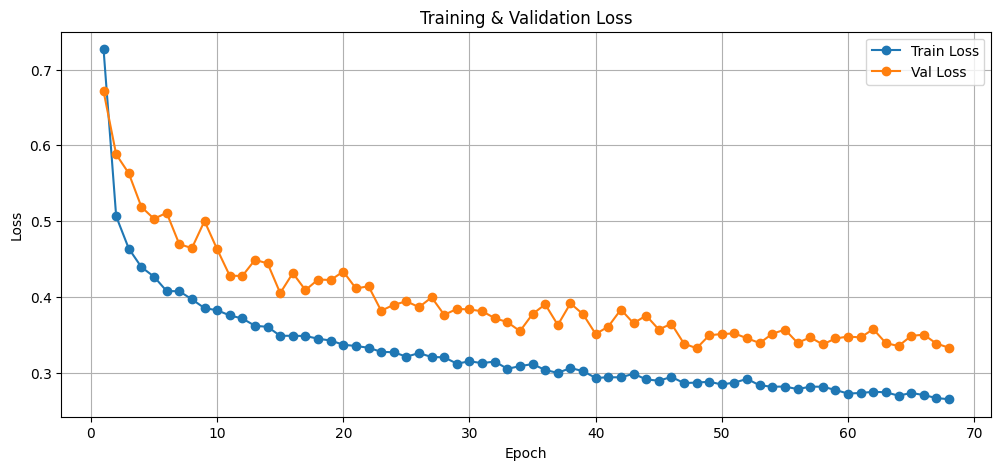

In [7]:
import os
import json
import cv2
import numpy as np
import mediapipe as mp
from tqdm import tqdm

# ── ML / DL
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# ── Plot
import matplotlib.pyplot as plt

# =========================
# 0) 설정
# =========================
LABELS = ['laugh', 'serious', 'surprise', 'yawn', 'none']
DATA_PATH = '../face_data'  # 라벨명과 동일한 폴더 구조 하위에 이미지가 있다고 가정
RANDOM_STATE = 42

# Mediapipe FaceMesh 인덱스 (주요 포인트)
IDX = {
    'upper_eye': 159, 'lower_eye': 145, 'eye_left': 33, 'eye_right': 133,
    'upper_lip': 13, 'lower_lip': 14, 'mouth_left': 61, 'mouth_right': 291, 'mouth_center': 0,
    'brow': 65, 'eye_center': 168, 'nose': 1, 'chin': 152,
    'cheek_l': 205, 'cheek_r': 425
}

# =========================
# 1) 특징 추출 함수 (12개)
#    - 기존 10개 + mouth_tilt + eye_mouth_coupling
# =========================
def extract_expression_features(landmarks):
    arr = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])

    # 기본 길이/비율
    eye_open = np.linalg.norm(arr[IDX['upper_eye']] - arr[IDX['lower_eye']])
    mouth_h  = np.linalg.norm(arr[IDX['upper_lip']] - arr[IDX['lower_lip']])
    mouth_w  = np.linalg.norm(arr[IDX['mouth_left']] - arr[IDX['mouth_right']])
    brow_lift = np.linalg.norm(arr[IDX['brow']] - arr[IDX['eye_center']])
    eye_w    = np.linalg.norm(arr[IDX['eye_left']] - arr[IDX['eye_right']])

    eye_ratio   = (eye_w / eye_open) if eye_open > 0 else 0.0
    mouth_ratio = (mouth_w / mouth_h) if mouth_h > 0 else 0.0
    brow_mouth_ratio = (brow_lift / mouth_h) if mouth_h > 0 else 0.0

    mouth_center_y = arr[IDX['mouth_center']][1]
    left_y  = arr[IDX['mouth_left']][1]
    right_y = arr[IDX['mouth_right']][1]
    mouth_droop = (left_y + right_y) / 2.0 - mouth_center_y
    mouth_asym  = abs(left_y - right_y)

    cheek_avg_z = (arr[IDX['cheek_l']][2] + arr[IDX['cheek_r']][2]) / 2.0
    nose_z = arr[IDX['nose']][2]
    cheek_puff = nose_z - cheek_avg_z  # 클수록 볼이 앞으로

    face_scale = np.linalg.norm(arr[IDX['nose']] - arr[IDX['chin']])
    if face_scale == 0:
        return np.zeros(12, dtype=np.float32)

    # 새 피처 1: 입선 기울기(스머크 탐지에 도움)
    dx = arr[IDX['mouth_right']][0] - arr[IDX['mouth_left']][0]
    dy = arr[IDX['mouth_right']][1] - arr[IDX['mouth_left']][1]
    mouth_tilt = np.arctan2(dy, dx) / (np.pi / 2)  # [-1, 1]

    # 새 피처 2: 눈-입 결합비(놀람 vs 하품 구분)
    eye_mouth_coupling = (eye_open / face_scale) / ((mouth_h / face_scale) + 1e-6)

    feats = np.array([
        eye_open / face_scale,         # 0
        mouth_h  / face_scale,         # 1
        mouth_w  / face_scale,         # 2
        brow_lift / face_scale,        # 3
        eye_ratio,                     # 4
        mouth_ratio,                   # 5
        brow_mouth_ratio,              # 6
        mouth_droop / face_scale,      # 7
        mouth_asym  / face_scale,      # 8
        cheek_puff  / face_scale,      # 9
        mouth_tilt,                    # 10
        eye_mouth_coupling             # 11
    ], dtype=np.float32)

    # 수치 안전장치
    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
    return feats


# =========================
# 2) 데이터 로드 & 특징 생성
# =========================
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, refine_landmarks=False, min_detection_confidence=0.7)

X, y = [], []
print("🔍 데이터 로딩 및 특징 추출 시작...")

for idx, label in enumerate(LABELS):
    folder = os.path.join(DATA_PATH, label)
    if not os.path.isdir(folder):
        print(f"⚠️ 폴더 없음: {folder} (건너뜀)")
        continue

    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for file in tqdm(files, desc=label):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        results = face_mesh.process(rgb)
        if results.multi_face_landmarks:
            landmarks = results.multi_face_landmarks[0].landmark
            feats = extract_expression_features(landmarks)
            X.append(feats)
            y.append(idx)

face_mesh.close()

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)
print("✅ 데이터셋 shape:", X.shape, y.shape)  # (N, 12), (N,)

# 품질 체크
if X.ndim != 2 or X.shape[0] == 0:
    raise RuntimeError("❌ 유효한 데이터가 없습니다. 이미지/라벨 경로를 확인하세요.")


# =========================
# 3) 데이터 분할 + 스케일링
# =========================
y_cat = to_categorical(y, num_classes=len(LABELS))
X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
y_train_int = np.argmax(y_train, axis=1)
y_val_int   = np.argmax(y_val, axis=1)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

# =========================
# 4) 클래스 가중치 + 모델 정의/학습
# =========================
cls_weight_vals = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_int), y=y_train_int)
class_weight = {i: w for i, w in enumerate(cls_weight_vals)}
print("📊 클래스 가중치:", class_weight)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(LABELS), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss')

history = model.fit(
    X_train_s, y_train,
    epochs=300,
    batch_size=64,
    validation_data=(X_val_s, y_val),
    callbacks=[es],
    class_weight=class_weight,
    verbose=1
)

# =========================
# 5) 기본 평가 (게이팅 적용 전)
# =========================
proba_val = model.predict(X_val_s, verbose=0)
pred_val  = np.argmax(proba_val, axis=1)

print("\n=== 기본 예측 (게이팅 전) ===")
print(classification_report(y_val_int, pred_val, target_names=LABELS, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_val_int, pred_val))

# =========================
# 6) Surprise 게이팅 임계 자동추정(훈련 셋 분포 기반 하위 25%)
# =========================
FEATURES = {
    "eye_open": 0,
    "mouth_h": 1,
    "mouth_w": 2,
    "brow_lift": 3,
    "eye_ratio": 4,
    "mouth_ratio": 5,
    "brow_mouth_ratio": 6,
    "mouth_droop": 7,
    "mouth_asym": 8,
    "cheek_puff": 9,
    "mouth_tilt": 10,
    "eye_mouth_coupling": 11,
}
SURPRISE_IDX = LABELS.index('surprise')

# 훈련셋 중 surprise 샘플에서 분위수 추정
surprise_mask = (y_train_int == SURPRISE_IDX)
if np.any(surprise_mask):
    s_mouth_h_q = np.percentile(X_train[surprise_mask, FEATURES["mouth_h"]], 25)
    s_eye_open_q = np.percentile(X_train[surprise_mask, FEATURES["eye_open"]], 25)
    s_brow_lift_q = np.percentile(X_train[surprise_mask, FEATURES["brow_lift"]], 25)
else:
    # 데이터가 거의 없을 때 보수적 기본값
    s_mouth_h_q, s_eye_open_q, s_brow_lift_q = 0.015, 0.012, 0.015

def gate_surprise(x_feat, proba, top_idx):
    """
    놀람으로 분류됐지만 입/눈/눈썹 상승이 모두 낮으면 차순위 클래스로 교체
    x_feat: 정규화 전 원본 특징(여기서는 face-normalized라 그냥 X 사용)
    """
    if top_idx != SURPRISE_IDX:
        return top_idx

    mouth_h = x_feat[FEATURES["mouth_h"]]
    eye_open = x_feat[FEATURES["eye_open"]]
    brow_lift = x_feat[FEATURES["brow_lift"]]

    if (mouth_h < s_mouth_h_q) and (eye_open < s_eye_open_q) and (brow_lift < s_brow_lift_q):
        second = np.argsort(proba)[-2]
        return second
    return top_idx

# 게이팅 적용한 예측
pred_val_gated = []
for i in range(len(X_val)):
    top = pred_val[i]
    adj = gate_surprise(X_val[i], proba_val[i], top)
    pred_val_gated.append(adj)
pred_val_gated = np.array(pred_val_gated, dtype=int)

print("\n=== 게이팅 적용 후(놀람 오탐 억제) ===")
print(classification_report(y_val_int, pred_val_gated, target_names=LABELS, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_val_int, pred_val_gated))

# =========================
# 7) 모델/스케일러/메타 저장
# =========================
MODEL_PATH = 'face_expression_landmark_model_enhanced_features_v3.h5'
SCALER_PATH = 'face_expression_scaler_v3.npy'
META_PATH   = 'face_expression_meta_v3.json'

model.save(MODEL_PATH)

# StandardScaler 저장 (간단히 mean/scale만 저장)
np.save(SCALER_PATH, {'mean_': scaler.mean_, 'scale_': scaler.scale_}, allow_pickle=True)

meta = {
    'labels': LABELS,
    'feature_index': FEATURES,
    'surprise_thresholds': {
        'mouth_h_q25': float(s_mouth_h_q),
        'eye_open_q25': float(s_eye_open_q),
        'brow_lift_q25': float(s_brow_lift_q)
    }
}
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"\n💾 저장 완료: {MODEL_PATH}, {SCALER_PATH}, {META_PATH}")

# =========================
# 8) 학습 곡선 시각화
# =========================
hist = history.history
epochs = range(1, len(hist['accuracy']) + 1)

plt.figure(figsize=(12, 5))
plt.plot(epochs, hist['accuracy'], 'o-', label='Train Acc')
plt.plot(epochs, hist['val_accuracy'], 'o-', label='Val Acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(True); plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(epochs, hist['loss'], 'o-', label='Train Loss')
plt.plot(epochs, hist['val_loss'], 'o-', label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True); plt.legend()
plt.show()


In [8]:
# =========================
# 9) TFLite 변환 (FP32 / Float16 / Int8)
# =========================
import tensorflow as tf
from pathlib import Path

OUT_DIR = Path("./export")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_bytes(path, blob):
    with open(path, "wb") as f:
        f.write(blob)
    size_mb = len(blob) / (1024 * 1024)
    print(f"✅ Saved: {path} ({size_mb:.2f} MB)")

# --- (1) 기본 FP32 (가장 호환성 좋음)
def convert_fp32(keras_model):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    tflite_model = converter.convert()
    save_bytes(OUT_DIR / "expression_landmark_fp32.tflite", tflite_model)

# --- (2) Float16 양자화 (용량↓, 속도↑, 입출력은 float32 유지)
def convert_float16(keras_model):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]  # 가중치 float16
    tflite_model = converter.convert()
    save_bytes(OUT_DIR / "expression_landmark_float16.tflite", tflite_model)

# --- (3) Int8 정수 양자화 (ARM/모바일에서 가장 빠름)
#      대표 데이터는 "모델 입력에 들어갈 값(=스케일러 적용된 X)"이어야 함
def representative_data_gen():
    # 너무 많이 줄 필요 없고 500~1000 샘플이면 충분
    n = min(1000, X_train_s.shape[0])
    for i in range(n):
        # 입력 shape: (1, 12), dtype=float32
        yield [X_train_s[i:i+1].astype(np.float32)]

def convert_int8(keras_model):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_data_gen
    # 완전 정수 양자화: 내부 op, 입출력까지 int8 (원하면 float32 I/O로 두어도 됨)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model = converter.convert()
    save_bytes(OUT_DIR / "expression_landmark_int8.tflite", tflite_model)

# 실행
convert_fp32(model)
convert_float16(model)
convert_int8(model)

print("🎉 TFLite 변환 완료! export/ 폴더를 확인하세요.")


INFO:tensorflow:Assets written to: C:\Users\SSAFY\AppData\Local\Temp\tmpfcb9er5c\assets


INFO:tensorflow:Assets written to: C:\Users\SSAFY\AppData\Local\Temp\tmpfcb9er5c\assets


✅ Saved: export\expression_landmark_fp32.tflite (0.04 MB)
INFO:tensorflow:Assets written to: C:\Users\SSAFY\AppData\Local\Temp\tmp5rrs4l3r\assets


INFO:tensorflow:Assets written to: C:\Users\SSAFY\AppData\Local\Temp\tmp5rrs4l3r\assets


✅ Saved: export\expression_landmark_float16.tflite (0.02 MB)
INFO:tensorflow:Assets written to: C:\Users\SSAFY\AppData\Local\Temp\tmpajvdft5i\assets


INFO:tensorflow:Assets written to: C:\Users\SSAFY\AppData\Local\Temp\tmpajvdft5i\assets


✅ Saved: export\expression_landmark_int8.tflite (0.01 MB)
🎉 TFLite 변환 완료! export/ 폴더를 확인하세요.


c:\Users\SSAFY\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\lite\python\convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## GPT 수정 버전

In [9]:
import os, json, cv2, numpy as np, tensorflow as tf, mediapipe as mp

# ====== 경로 ======
TFLITE_PATH = "../templates/expression_landmark_fp32.tflite"
SCALER_PATH = "../face_expression_scaler_v3.npy"
META_PATH   = "../face_expression_meta_v3.json"

LABELS = ['laugh', 'serious', 'surprise', 'yawn', 'none']
IDX = {l:i for i,l in enumerate(LABELS)}

# ── 라벨별 표시 임계값
SHOW_THRESH = {
    "serious": 0.60,   # 요구사항
    "surprise": 0.90,
    "laugh": 0.90,
    "yawn": 0.90,
    "none": 0.90,
}

# ── tflite 로드
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
in_det  = interpreter.get_input_details()[0]
out_det = interpreter.get_output_details()[0]
input_index  = in_det['index']
output_index = out_det['index']
assert in_det['dtype'] == np.float32, "fp32 모델이 맞는지 확인해줘!"

# ── 스케일러(mean_/scale_) 로드
scaler_blob = np.load(SCALER_PATH, allow_pickle=True).item()
MEAN = scaler_blob['mean_'].astype(np.float32)
SCALE = scaler_blob['scale_'].astype(np.float32)

# ── meta(게이팅 임계) 로드 (없으면 기본값)
if os.path.exists(META_PATH):
    with open(META_PATH, 'r', encoding='utf-8') as f:
        META = json.load(f)
    THR = META.get('surprise_thresholds', {})
    MOUTH_H_Q25 = float(THR.get('mouth_h_q25', 0.015))
    EYE_OPEN_Q25 = float(THR.get('eye_open_q25', 0.012))
    BROW_LIFT_Q25 = float(THR.get('brow_lift_q25', 0.015))
else:
    MOUTH_H_Q25, EYE_OPEN_Q25, BROW_LIFT_Q25 = 0.015, 0.012, 0.015

# ── Mediapipe
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(max_num_faces=1, refine_landmarks=False, min_detection_confidence=0.7)

# ── 주요 인덱스
IDX_FM = {
    'upper_eye': 159, 'lower_eye': 145, 'eye_left': 33, 'eye_right': 133,
    'upper_lip': 13, 'lower_lip': 14, 'mouth_left': 61, 'mouth_right': 291, 'mouth_center': 0,
    'brow': 65, 'eye_center': 168, 'nose': 1, 'chin': 152, 'cheek_l': 205, 'cheek_r': 425
}

# ── 12개 피처 (훈련과 동일)
def extract_features12(landmarks):
    arr = np.array([[lm.x, lm.y, lm.z] for lm in landmarks], dtype=np.float32)

    eye_open = np.linalg.norm(arr[IDX_FM['upper_eye']] - arr[IDX_FM['lower_eye']])
    mouth_h  = np.linalg.norm(arr[IDX_FM['upper_lip']] - arr[IDX_FM['lower_lip']])
    mouth_w  = np.linalg.norm(arr[IDX_FM['mouth_left']] - arr[IDX_FM['mouth_right']])
    brow_lift = np.linalg.norm(arr[IDX_FM['brow']] - arr[IDX_FM['eye_center']])
    eye_w    = np.linalg.norm(arr[IDX_FM['eye_left']] - arr[IDX_FM['eye_right']])

    eye_ratio   = (eye_w / eye_open) if eye_open > 0 else 0.0
    mouth_ratio = (mouth_w / mouth_h) if mouth_h > 0 else 0.0
    brow_mouth_ratio = (brow_lift / mouth_h) if mouth_h > 0 else 0.0

    mouth_center_y = arr[IDX_FM['mouth_center']][1]
    left_y  = arr[IDX_FM['mouth_left']][1]
    right_y = arr[IDX_FM['mouth_right']][1]
    mouth_droop = (left_y + right_y) / 2.0 - mouth_center_y
    mouth_asym  = abs(left_y - right_y)

    cheek_avg_z = (arr[IDX_FM['cheek_l']][2] + arr[IDX_FM['cheek_r']][2]) / 2.0
    nose_z = arr[IDX_FM['nose']][2]
    cheek_puff = nose_z - cheek_avg_z

    face_scale = np.linalg.norm(arr[IDX_FM['nose']] - arr[IDX_FM['chin']])
    if face_scale == 0:
        return np.zeros(12, dtype=np.float32)

    dx = arr[IDX_FM['mouth_right']][0] - arr[IDX_FM['mouth_left']][0]
    dy = arr[IDX_FM['mouth_right']][1] - arr[IDX_FM['mouth_left']][1]
    mouth_tilt = np.arctan2(dy, dx) / (np.pi / 2)     # [-1,1]
    eye_mouth_coupling = (eye_open / face_scale) / ((mouth_h / face_scale) + 1e-6)

    feats = np.array([
        eye_open / face_scale,        # 0
        mouth_h  / face_scale,        # 1
        mouth_w  / face_scale,        # 2
        brow_lift / face_scale,       # 3
        eye_ratio,                    # 4
        mouth_ratio,                  # 5
        brow_mouth_ratio,             # 6
        mouth_droop / face_scale,     # 7
        mouth_asym  / face_scale,     # 8
        cheek_puff  / face_scale,     # 9
        mouth_tilt,                   # 10
        eye_mouth_coupling            # 11
    ], dtype=np.float32)
    return np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)

# ── 놀람 게이팅
def gate_surprise(raw_feat, probs, top_idx):
    if top_idx != IDX['surprise']:
        return top_idx
    if (raw_feat[1] < MOUTH_H_Q25) and (raw_feat[0] < EYE_OPEN_Q25) and (raw_feat[3] < BROW_LIFT_Q25):
        return int(np.argsort(probs)[-2])
    return top_idx

# ── serious 승격 (스머크/찡그림/볼빵빵 + 확률)
#    * 임계는 데이터에 맞춰 살짝 조정 가능
SMIRK_T = 0.010   # mouth_asym >
FROWN_T = 0.018   # brow_lift <
PUFF_T  = 0.015   # cheek_puff >
def promote_serious(raw_feat, probs, current_idx):
    serious_p = float(probs[IDX['serious']])
    smirk = raw_feat[8] > SMIRK_T
    frown = raw_feat[3] < FROWN_T
    puff  = raw_feat[9] > PUFF_T
    # 조건 1) serious 확률 자체가 0.60 이상이거나
    # 조건 2) 특징 신호가 있고 serious 확률이 0.45 이상이면 승격
    if serious_p >= 0.60 or ((smirk or frown or puff) and serious_p >= 0.45):
        return IDX['serious'], serious_p
    return current_idx, float(probs[current_idx])

# ── PNG 오버레이
def read_png(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    return img if (img is not None and img.ndim == 3 and img.shape[2] == 4) else None

surprise_img = read_png("../face_data/surprise.png")
laugh_img    = read_png("../face_data/laugh.png")
yawn_img     = read_png("../face_data/yawn.png")

def overlay_image(bg, ov, x, y, scale=0.15):
    if ov is None: return bg
    h,w = ov.shape[:2]
    ow, oh = int(w*scale), int(h*scale)
    ov = cv2.resize(ov, (ow, oh))
    y1,y2 = y, y+oh; x1,x2 = x, x+ow
    if y1<0 or x1<0 or y2>bg.shape[0] or x2>bg.shape[1]: return bg
    alpha = ov[:,:,3]/255.0
    for c in range(3):
        bg[y1:y2, x1:x2, c] = alpha*ov[:,:,c] + (1-alpha)*bg[y1:y2, x1:x2, c]
    return bg

# ── 확률 EMA(선택)
PROBA_ALPHA = 0.3
proba_smooth = None
def smooth(p):
    global proba_smooth
    proba_smooth = p if proba_smooth is None else (1-PROBA_ALPHA)*proba_smooth + PROBA_ALPHA*p
    return proba_smooth

# ====== 웹캠 ======
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise SystemExit("❌ 카메라 열기 실패")

print("🎥 'q'로 종료")
while True:
    ok, frame = cap.read()
    if not ok: break
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    if results.multi_face_landmarks:
        lms = results.multi_face_landmarks[0].landmark
        feat_raw = extract_features12(lms)
        feat_std = (feat_raw - MEAN) / (SCALE + 1e-8)

        inp = feat_std.reshape(1, -1).astype(np.float32)
        interpreter.set_tensor(input_index, inp)
        interpreter.invoke()
        probs = interpreter.get_tensor(output_index)[0]
        probs = smooth(probs)

        # 1) 기본 top
        top = int(np.argmax(probs))
        # 2) 놀람 게이팅
        top = gate_surprise(feat_raw, probs, top)
        # 3) serious 승격
        top, conf = promote_serious(feat_raw, probs, top)

        label = LABELS[top]
        show_th = SHOW_THRESH.get(label, 0.90)

        fixed_x, fixed_y = 10, 10
        if conf >= show_th:
            if label == "surprise": frame = overlay_image(frame, surprise_img, fixed_x, fixed_y, 0.15)
            elif label == "laugh":  frame = overlay_image(frame,   laugh_img, fixed_x, fixed_y, 0.15)
            elif label == "yawn":   frame = overlay_image(frame,    yawn_img, fixed_x, fixed_y, 0.15)
            elif label == "serious":
                cv2.putText(frame, "serious", (fixed_x, fixed_y+30),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,255,0), 3)
            else:
                cv2.putText(frame, "none", (fixed_x, fixed_y+30),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,255,0), 3)
        else:
            cv2.putText(frame, f"{label} ({conf:.2f})", (fixed_x, fixed_y+30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,0), 2)

    cv2.imshow("Expression (Landmark, 12F + Scaler)", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()


🎥 'q'로 종료
